In [1]:
import pandas as pd

# Example dataset
data = {'Color': ['Red', 'Blue', 'Green', 'Blue', 'Red']}
df = pd.DataFrame(data)

In [2]:
# One-hot encoding
encoded_df = pd.get_dummies(df, columns=['Color'], drop_first=False)
print(encoded_df)

   Color_Blue  Color_Green  Color_Red
0       False        False       True
1        True        False      False
2       False         True      False
3        True        False      False
4       False        False       True


In [3]:
#Label encoding
from sklearn.preprocessing import LabelEncoder

# Example
label_encoder = LabelEncoder()
df['Color_Label'] = label_encoder.fit_transform(df['Color'])
print(df)

   Color  Color_Label
0    Red            2
1   Blue            0
2  Green            1
3   Blue            0
4    Red            2


In [4]:
#frequency encoding
frequency_map = df['Color'].value_counts().to_dict()
df['Color_Frequency'] = df['Color'].map(frequency_map)
print(df)


   Color  Color_Label  Color_Frequency
0    Red            2                2
1   Blue            0                2
2  Green            1                1
3   Blue            0                2
4    Red            2                2


In [5]:
#handling numerical value
# a. Polynomial Features Generate polynomial combinations of existing features.
# Add the missing columns 'Feature1' and 'Feature2' to the DataFrame
# Example values are used, you should replace them with your actual data
import numpy as np
df['Feature1'] = np.random.rand(len(df))
df['Feature2'] = np.random.rand(len(df))

# Now you can proceed with PolynomialFeatures
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, interaction_only=False, include_bias=False)
poly_features = poly.fit_transform(df[['Feature1', 'Feature2']])
poly_features

array([[0.53990105, 0.09131462, 0.29149314, 0.04930086, 0.00833836],
       [0.84261843, 0.058966  , 0.71000581, 0.04968584, 0.00347699],
       [0.6271296 , 0.03107508, 0.39329154, 0.0194881 , 0.00096566],
       [0.56285977, 0.73033547, 0.31681112, 0.41107645, 0.53338989],
       [0.88960034, 0.17367737, 0.79138877, 0.15450345, 0.03016383]])

In [6]:
# Add a 'Value' column to the DataFrame with example data
# Replace this with your actual data if you have it
df['Value'] = np.random.rand(len(df))

# Now calculate the rolling mean and standard deviation
df['Rolling_Mean'] = df['Value'].rolling(window=3).mean()
df['Rolling_Std'] = df['Value'].rolling(window=3).std()

In [7]:
df

,Color,Color_Label,Color_Frequency,Feature1,Feature2,Value,Rolling_Mean,Rolling_Std
0,Red,2,2,0.539901,0.091315,0.683760,NaN,NaN
1,Blue,0,2,0.842618,0.058966,0.947904,NaN,NaN
2,Green,1,1,0.627130,0.031075,0.114934,0.582199,0.425670
3,Blue,0,2,0.562860,0.730335,0.104647,0.389162,0.483912
4,Red,2,2,0.889600,0.173677,0.835638,0.351740,0.419099


In [8]:
# correlation analysis
# Calculate the correlation coefficient between numerical features and the target variable.
# Convert 'Color', 'Color_Label' and 'Color_Frequency' to numeric if possible.
# If not possible to convert, drop them before calculating correlation.
# df['Target'] = np.random.rand(len(df))

# Option 1: Drop non-numeric columns
numerical_df = df.select_dtypes(include=np.number)
correlation = numerical_df.corr()
print(correlation['Feature1'])

# Option 2: Convert 'Color_Label' and 'Color_Frequency' to numeric
# (assuming they represent ordinal or frequency data) and drop 'Color'
for col in ['Color_Label', 'Color_Frequency']:
  df[col] = pd.to_numeric(df[col], errors='coerce') # Handle potential errors
numerical_df = df.drop(columns=['Color']) # Drop the original 'Color' column
correlation = numerical_df.corr()
print(correlation['Feature1'])

Color_Label        0.036937
Color_Frequency    0.224479
Feature1           1.000000
Feature2          -0.355482
Value              0.696268
Rolling_Mean      -0.469517
Rolling_Std       -0.719134
Name: Feature1, dtype: float64
Color_Label        0.036937
Color_Frequency    0.224479
Feature1           1.000000
Feature2          -0.355482
Value              0.696268
Rolling_Mean      -0.469517
Rolling_Std       -0.719134
Name: Feature1, dtype: float64


In [9]:
#Chi-Square Test
#Used for categorical data to measure dependency between features and the target.
from sklearn.feature_selection import f_regression, SelectKBest # Import f_regression
import pandas as pd
import numpy as np

# Assuming 'df' is your DataFrame and 'Target' is the target column
# If you don't have a 'Target' column, replace it with your target variable
df['Target'] = np.random.rand(len(df))
# Replace 'Target' with your target column if it exists
# and make sure 'df' contains all necessary data

# Define X and y
X = df.drop(columns=['Target', 'Color']) # Features (excluding the target)
y = df['Target'] # Target variable

# Impute or drop NaN values in X before applying SelectKBest
# Option 1: Drop rows with NaN values
X = X.dropna()
y = y[X.index] # Ensure y is aligned with X after dropping rows

# Option 2: Impute NaN values with the mean of each column
# from sklearn.impute import SimpleImputer
# imputer = SimpleImputer(strategy='mean')
# X = imputer.fit_transform(X)

# Now apply SelectKBest with f_regression for continuous target
X_new = SelectKBest(f_regression, k=5).fit_transform(X, y) # Use f_regression
print(X_new)

[[1.         0.6271296  0.11493445 0.58219945 0.42567048]
 [0.         0.56285977 0.1046473  0.38916179 0.48391195]
 [2.         0.88960034 0.83563769 0.35173981 0.41909942]]


In [10]:
'''
Wrapper Methods
Wrapper methods evaluate feature subsets by training a model and optimizing performance.
a. Recursive Feature Elimination (RFE) Uses a model to recursively remove the least important features. b.Forward/Backward Selection
Forward: Add features iteratively.
Backward: Remove features iteratively.
Tools: mlxtend.feature_selection.SequentialFeatureSelector.
'''

'\nWrapper Methods \nWrapper methods evaluate feature subsets by training a model and optimizing performance. \na. Recursive Feature Elimination (RFE) Uses a model to recursively remove the least important features. b.Forward/Backward Selection \nForward: Add features iteratively. \nBackward: Remove features iteratively. \nTools: mlxtend.feature_selection.SequentialFeatureSelector.\n'

In [11]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression # Import LinearRegression
# ... (Your existing code) ...
model = LinearRegression() # Use LinearRegression instead of LogisticRegression
rfe = RFE(model, n_features_to_select=5)
X_rfe = rfe.fit_transform(X, y)
print(rfe.support_)


[ True  True  True False  True  True False]


In [12]:
'''

Embedded Methods Embedded methods combine feature selection with model training.
a. L1 Regularization (Lasso Regression) Adds a penalty term to the loss function to reduce feature coefficients.
b. Tree-Based Methods Tree-based algorithms like Random Forest or XGBoost provide feature importance scores.
Experimentation with Feature Engineering Experimenting with feature engineering often requires iterative testing and validation. Here's a step-
by-step guide:
a. Exploratory Data Analysis (EDA) Plot distributions to detect patterns. Use scatterplots to examine relationships.
b. New Feature Creation Combine existing features, e.g., interaction terms. Generate ratios or differences: feature1 / feature2, feature1 -
feature2.
c. Dimensionality Reduction Use techniques like PCA (Principal Component Analysis) for high-dimensional data.
'''

"\n \nEmbedded Methods Embedded methods combine feature selection with model training. \na. L1 Regularization (Lasso Regression) Adds a penalty term to the loss function to reduce feature coefficients. \nb. Tree-Based Methods Tree-based algorithms like Random Forest or XGBoost provide feature importance scores. \nExperimentation with Feature Engineering Experimenting with feature engineering often requires iterative testing and validation. Here's a step- \nby-step guide: \na. Exploratory Data Analysis (EDA) Plot distributions to detect patterns. Use scatterplots to examine relationships. \nb. New Feature Creation Combine existing features, e.g., interaction terms. Generate ratios or differences: feature1 / feature2, feature1 - \nfeature2. \nc. Dimensionality Reduction Use techniques like PCA (Principal Component Analysis) for high-dimensional data. \n"

In [13]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.01)
lasso.fit(X, y)
print(lasso.coef_)

[ 0.11172283  0.0689589   0.          0.          0.         -0.
 -0.        ]


In [14]:
from sklearn.ensemble import RandomForestRegressor # Import RandomForestRegressor

model = RandomForestRegressor() # Use RandomForestRegressor for continuous target
model.fit(X, y)
importance = model.feature_importances_
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

In [15]:
'''

Validate Feature Effectiveness
Use cross-validation to evaluate new features.
Compare model metrics like accuracy, precision, recall, or F1-score before and after adding/removing features.
'''

'\n \nValidate Feature Effectiveness \nUse cross-validation to evaluate new features. \nCompare model metrics like accuracy, precision, recall, or F1-score before and after adding/removing features.\n'

In [16]:
import pandas as pd
import numpy as np
import seaborn as sns

In [17]:
train = pd.read_csv('/content/train.csv')
test = pd.read_csv('/content/test.csv')
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [18]:
test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [19]:
train["Pclass"].value_counts()


,count
Pclass,
3,491
1,216
2,184


In [20]:
train.isna().sum()


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [21]:
train.dtypes


,0
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64


In [22]:
train.drop(['Name'], axis=1, inplace = True)

#train = train.drop(['Name'], axis=1)
train

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,male,26.0,0,0,111369,30.0000,C148,C


In [23]:
train_sex = pd.get_dummies(train['Sex'])
train2 = pd.concat([train, train_sex], axis = 1)
train2.drop(['Sex'], axis=1, inplace = True)
train2

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,female,male
0,1,0,3,22.0,1,0,A/5 21171,7.2500,NaN,S,False,True
1,2,1,1,38.0,1,0,PC 17599,71.2833,C85,C,True,False
2,3,1,3,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,True,False
3,4,1,1,35.0,1,0,113803,53.1000,C123,S,True,False
4,5,0,3,35.0,0,0,373450,8.0500,NaN,S,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,27.0,0,0,211536,13.0000,NaN,S,False,True
887,888,1,1,19.0,0,0,112053,30.0000,B42,S,True,False
888,889,0,3,NaN,1,2,W./C. 6607,23.4500,NaN,S,True,False
889,890,1,1,26.0,0,0,111369,30.0000,C148,C,False,True


In [24]:
train2.Cabin.unique()


array([nan, 'C85', 'C123', 'E46', 'G6', 'C103', 'D56', 'A6',
       'C23 C25 C27', 'B78', 'D33', 'B30', 'C52', 'B28', 'C83', 'F33',
       'F G73', 'E31', 'A5', 'D10 D12', 'D26', 'C110', 'B58 B60', 'E101',
       'F E69', 'D47', 'B86', 'F2', 'C2', 'E33', 'B19', 'A7', 'C49', 'F4',
       'A32', 'B4', 'B80', 'A31', 'D36', 'D15', 'C93', 'C78', 'D35',
       'C87', 'B77', 'E67', 'B94', 'C125', 'C99', 'C118', 'D7', 'A19',
       'B49', 'D', 'C22 C26', 'C106', 'C65', 'E36', 'C54',
       'B57 B59 B63 B66', 'C7', 'E34', 'C32', 'B18', 'C124', 'C91', 'E40',
       'T', 'C128', 'D37', 'B35', 'E50', 'C82', 'B96 B98', 'E10', 'E44',
       'A34', 'C104', 'C111', 'C92', 'E38', 'D21', 'E12', 'E63', 'A14',
       'B37', 'C30', 'D20', 'B79', 'E25', 'D46', 'B73', 'C95', 'B38',
       'B39', 'B22', 'C86', 'C70', 'A16', 'C101', 'C68', 'A10', 'E68',
       'B41', 'A20', 'D19', 'D50', 'D9', 'A23', 'B50', 'A26', 'D48',
       'E58', 'C126', 'B71', 'B51 B53 B55', 'D49', 'B5', 'B20', 'F G63',
       'C62 C64',

In [25]:
train2.Ticket.unique()


array(['A/5 21171', 'PC 17599', 'STON/O2. 3101282', '113803', '373450',
       '330877', '17463', '349909', '347742', '237736', 'PP 9549',
       '113783', 'A/5. 2151', '347082', '350406', '248706', '382652',
       '244373', '345763', '2649', '239865', '248698', '330923', '113788',
       '347077', '2631', '19950', '330959', '349216', 'PC 17601',
       'PC 17569', '335677', 'C.A. 24579', 'PC 17604', '113789', '2677',
       'A./5. 2152', '345764', '2651', '7546', '11668', '349253',
       'SC/Paris 2123', '330958', 'S.C./A.4. 23567', '370371', '14311',
       '2662', '349237', '3101295', 'A/4. 39886', 'PC 17572', '2926',
       '113509', '19947', 'C.A. 31026', '2697', 'C.A. 34651', 'CA 2144',
       '2669', '113572', '36973', '347088', 'PC 17605', '2661',
       'C.A. 29395', 'S.P. 3464', '3101281', '315151', 'C.A. 33111',
       'S.O.C. 14879', '2680', '1601', '348123', '349208', '374746',
       '248738', '364516', '345767', '345779', '330932', '113059',
       'SO/C 14885', '31012

In [26]:
train2.Embarked.unique()


array(['S', 'C', 'Q', nan], dtype=object)

In [27]:
train2.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [28]:
train2


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,female,male
0,1,0,3,22.0,1,0,A/5 21171,7.2500,NaN,S,False,True
1,2,1,1,38.0,1,0,PC 17599,71.2833,C85,C,True,False
2,3,1,3,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,True,False
3,4,1,1,35.0,1,0,113803,53.1000,C123,S,True,False
4,5,0,3,35.0,0,0,373450,8.0500,NaN,S,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,27.0,0,0,211536,13.0000,NaN,S,False,True
887,888,1,1,19.0,0,0,112053,30.0000,B42,S,True,False
888,889,0,3,NaN,1,2,W./C. 6607,23.4500,NaN,S,True,False
889,890,1,1,26.0,0,0,111369,30.0000,C148,C,False,True


In [29]:
survived = train2[train2["Survived"] == 1]
notsurvived = train2[train2["Survived"] != 1]

print(survived.shape)
print(notsurvived.shape)

(342, 12)
(549, 12)


In [30]:
print(survived.shape[0])
print(notsurvived.shape[0])
print(survived["female"].sum())
print(notsurvived["female"].sum())
print(survived["female"].sum()/survived.shape[0])
print(notsurvived["female"].sum()/notsurvived.shape[0])

342
549
233
81
0.6812865497076024
0.14754098360655737


In [31]:
survived


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,female,male
1,2,1,1,38.0,1,0,PC 17599,71.2833,C85,C,True,False
2,3,1,3,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,True,False
3,4,1,1,35.0,1,0,113803,53.1000,C123,S,True,False
8,9,1,3,27.0,0,2,347742,11.1333,NaN,S,True,False
9,10,1,2,14.0,1,0,237736,30.0708,NaN,C,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
875,876,1,3,15.0,0,0,2667,7.2250,NaN,C,True,False
879,880,1,1,56.0,0,1,11767,83.1583,C50,C,True,False
880,881,1,2,25.0,0,1,230433,26.0000,NaN,S,True,False
887,888,1,1,19.0,0,0,112053,30.0000,B42,S,True,False


In [32]:
survived.describe()


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,342.000000,342.0,342.000000,290.000000,342.000000,342.000000,342.000000
mean,444.368421,1.0,1.950292,28.343690,0.473684,0.464912,48.395408
std,252.358840,0.0,0.863321,14.950952,0.708688,0.771712,66.596998
min,2.000000,1.0,1.000000,0.420000,0.000000,0.000000,0.000000
25%,250.750000,1.0,1.000000,19.000000,0.000000,0.000000,12.475000
50%,439.500000,1.0,2.000000,28.000000,0.000000,0.000000,26.000000
75%,651.500000,1.0,3.000000,36.000000,1.000000,1.000000,57.000000
max,890.000000,1.0,3.000000,80.000000,4.000000,5.000000,512.329200


In [33]:
notsurvived.describe()


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,549.000000,549.0,549.000000,424.000000,549.000000,549.000000,549.000000
mean,447.016393,0.0,2.531876,30.626179,0.553734,0.329690,22.117887
std,260.640469,0.0,0.735805,14.172110,1.288399,0.823166,31.388207
min,1.000000,0.0,1.000000,1.000000,0.000000,0.000000,0.000000
25%,211.000000,0.0,2.000000,21.000000,0.000000,0.000000,7.854200
50%,455.000000,0.0,3.000000,28.000000,0.000000,0.000000,10.500000
75%,675.000000,0.0,3.000000,39.000000,1.000000,0.000000,26.000000
max,891.000000,0.0,3.000000,74.000000,8.000000,6.000000,263.000000


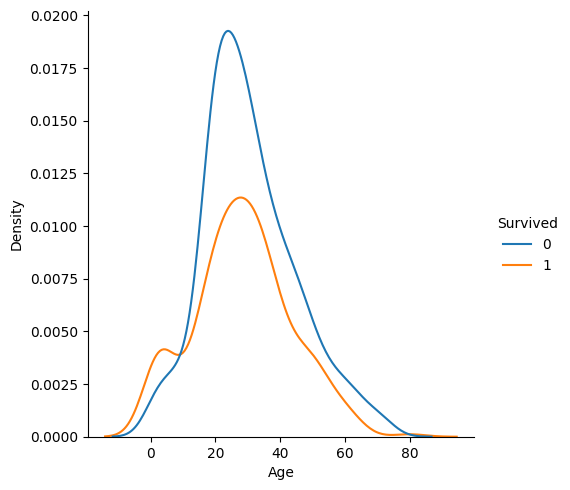

In [34]:
sns.displot(train, x="Age", hue="Survived", kind="kde")


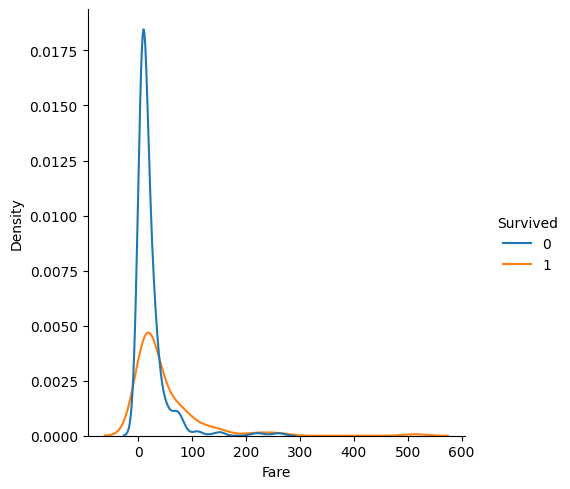

In [35]:
sns.displot(train, x="Fare", hue="Survived", kind="kde")


In [36]:
train_Embarked = pd.get_dummies(train2['Embarked'])
train3 = pd.concat([train2, train_Embarked], axis = 1)
train3.drop(['Embarked'], axis=1, inplace = True)
train3

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Ticket,Fare,Cabin,female,male,C,Q,S
0,1,0,3,22.0,1,0,A/5 21171,7.2500,NaN,False,True,False,False,True
1,2,1,1,38.0,1,0,PC 17599,71.2833,C85,True,False,True,False,False
2,3,1,3,26.0,0,0,STON/O2. 3101282,7.9250,NaN,True,False,False,False,True
3,4,1,1,35.0,1,0,113803,53.1000,C123,True,False,False,False,True
4,5,0,3,35.0,0,0,373450,8.0500,NaN,False,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,27.0,0,0,211536,13.0000,NaN,False,True,False,False,True
887,888,1,1,19.0,0,0,112053,30.0000,B42,True,False,False,False,True
888,889,0,3,NaN,1,2,W./C. 6607,23.4500,NaN,True,False,False,False,True
889,890,1,1,26.0,0,0,111369,30.0000,C148,False,True,True,False,False


In [37]:
train3.drop(['Ticket','Cabin'], axis=1, inplace = True)
train3

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,female,male,C,Q,S
0,1,0,3,22.0,1,0,7.2500,False,True,False,False,True
1,2,1,1,38.0,1,0,71.2833,True,False,True,False,False
2,3,1,3,26.0,0,0,7.9250,True,False,False,False,True
3,4,1,1,35.0,1,0,53.1000,True,False,False,False,True
4,5,0,3,35.0,0,0,8.0500,False,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,27.0,0,0,13.0000,False,True,False,False,True
887,888,1,1,19.0,0,0,30.0000,True,False,False,False,True
888,889,0,3,NaN,1,2,23.4500,True,False,False,False,True
889,890,1,1,26.0,0,0,30.0000,False,True,True,False,False


In [38]:
train3.dtypes


,0
PassengerId,int64
Survived,int64
Pclass,int64
Age,float64
SibSp,int64
Parch,int64
Fare,float64
female,bool
male,bool
C,bool


In [39]:
print(" \nCount total NaN at each column in a DataFrame : \n\n",
train2.isnull().sum())

 
Count total NaN at each column in a DataFrame : 

 PassengerId      0
Survived         0
Pclass           0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
female           0
male             0
dtype: int64


In [40]:
train3


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,female,male,C,Q,S
0,1,0,3,22.0,1,0,7.2500,False,True,False,False,True
1,2,1,1,38.0,1,0,71.2833,True,False,True,False,False
2,3,1,3,26.0,0,0,7.9250,True,False,False,False,True
3,4,1,1,35.0,1,0,53.1000,True,False,False,False,True
4,5,0,3,35.0,0,0,8.0500,False,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,27.0,0,0,13.0000,False,True,False,False,True
887,888,1,1,19.0,0,0,30.0000,True,False,False,False,True
888,889,0,3,NaN,1,2,23.4500,True,False,False,False,True
889,890,1,1,26.0,0,0,30.0000,False,True,True,False,False


In [41]:
# Feature extraction
mean = train3['Age'].mean()
train3['Age'].replace(np.nan,mean, inplace = True)


/tmp/ipykernel_5665/242793807.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train3['Age'].replace(np.nan,mean, inplace = True)


In [42]:
# Import the PCA function from sklearn
from sklearn.decomposition import PCA

# Select the number of principal components we will return
num_components = 4

# Create the PCA model
pca = PCA(n_components=num_components)

# Fit the model with the standardised data
pca_data = pca.fit_transform(train3[["Pclass","Age","SibSp","Parch","Fare","female","male" , "C","Q", "S"]])

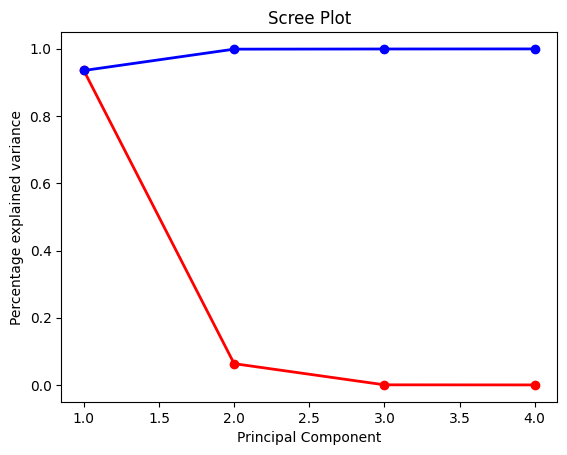

In [43]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

PC_values = np.arange(pca.n_components_) + 1
plt.plot(PC_values, pca.explained_variance_ratio_, 'ro-', linewidth=2)
plt.plot(PC_values, pca.explained_variance_ratio_.cumsum(), 'bo-', linewidth=2)
plt.title('Scree Plot')
plt.xlabel('Principal Component')
plt.ylabel('Percentage explained variance')
plt.show()

In [44]:
pca.explained_variance_ratio_


array([9.35395822e-01, 6.34736653e-02, 4.80333654e-04, 1.98753055e-04])

In [45]:
pca_data


array([[-2.51503059e+01, -7.06635416e+00,  2.28322641e-01,
        -7.83780379e-01],
       [ 3.92946604e+01,  7.30274101e+00,  1.69236863e-01,
         3.91357585e-01],
       [-2.43728064e+01, -3.07317398e+00, -4.30444433e-01,
         4.82956772e-01],
       ...,
       [-8.74837108e+00,  1.76983497e-01,  1.32942928e+00,
         1.34482152e+00],
       [-2.28778282e+00, -3.59667531e+00, -1.00443582e+00,
        -2.89845185e-02],
       [-2.43962296e+01,  2.93435060e+00, -4.55750591e-01,
        -3.99343727e-01]])

In [46]:
pca_data2 = pd.DataFrame(pca_data)
pca_data2

,0,1,2,3
0,-25.150306,-7.066354,0.228323,-0.783780
1,39.294660,7.302741,0.169237,0.391358
2,-24.372806,-3.073174,-0.430444,0.482957
3,21.037784,4.772290,0.270861,0.369579
4,-24.020104,5.923856,-0.316544,-0.454950
...,...,...,...,...
886,-19.268322,-2.178872,-0.676500,-0.268982
887,-2.467769,-10.599115,-0.957935,0.800018
888,-8.748371,0.176983,1.329429,1.344822
889,-2.287783,-3.596675,-1.004436,-0.028985


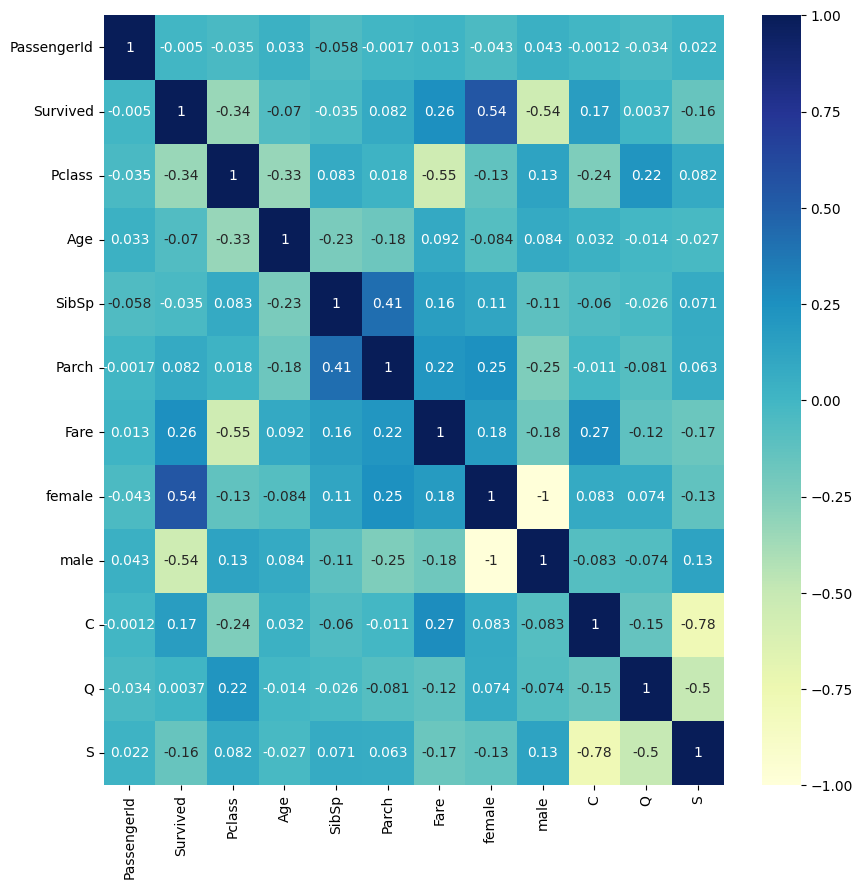

In [47]:
# feature selection correlation matrix
import seaborn as sns
import matplotlib.pyplot
from matplotlib.pyplot import figure
plt.figure(figsize=(10, 10))
# plotting correlation heatmap
dataplot = sns.heatmap(train3.corr(), cmap="YlGnBu", annot=True)
# displaying heatmap
plt.show()

In [48]:
train3


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,female,male,C,Q,S
0,1,0,3,22.000000,1,0,7.2500,False,True,False,False,True
1,2,1,1,38.000000,1,0,71.2833,True,False,True,False,False
2,3,1,3,26.000000,0,0,7.9250,True,False,False,False,True
3,4,1,1,35.000000,1,0,53.1000,True,False,False,False,True
4,5,0,3,35.000000,0,0,8.0500,False,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,27.000000,0,0,13.0000,False,True,False,False,True
887,888,1,1,19.000000,0,0,30.0000,True,False,False,False,True
888,889,0,3,29.699118,1,2,23.4500,True,False,False,False,True
889,890,1,1,26.000000,0,0,30.0000,False,True,True,False,False


In [49]:
# feature selection with ANOVA
survived = train[train["Survived"] == 1]
survived.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,342.000000,342.0,342.000000,290.000000,342.000000,342.000000,342.000000
mean,444.368421,1.0,1.950292,28.343690,0.473684,0.464912,48.395408
std,252.358840,0.0,0.863321,14.950952,0.708688,0.771712,66.596998
min,2.000000,1.0,1.000000,0.420000,0.000000,0.000000,0.000000
25%,250.750000,1.0,1.000000,19.000000,0.000000,0.000000,12.475000
50%,439.500000,1.0,2.000000,28.000000,0.000000,0.000000,26.000000
75%,651.500000,1.0,3.000000,36.000000,1.000000,1.000000,57.000000
max,890.000000,1.0,3.000000,80.000000,4.000000,5.000000,512.329200


In [50]:
notsurvived = train[train["Survived"] == 0]
notsurvived.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,549.000000,549.0,549.000000,424.000000,549.000000,549.000000,549.000000
mean,447.016393,0.0,2.531876,30.626179,0.553734,0.329690,22.117887
std,260.640469,0.0,0.735805,14.172110,1.288399,0.823166,31.388207
min,1.000000,0.0,1.000000,1.000000,0.000000,0.000000,0.000000
25%,211.000000,0.0,2.000000,21.000000,0.000000,0.000000,7.854200
50%,455.000000,0.0,3.000000,28.000000,0.000000,0.000000,10.500000
75%,675.000000,0.0,3.000000,39.000000,1.000000,0.000000,26.000000
max,891.000000,0.0,3.000000,74.000000,8.000000,6.000000,263.000000


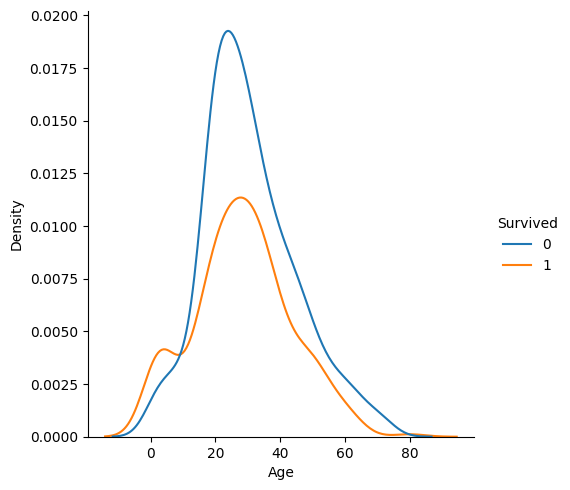

In [51]:
sns.displot(train, x="Age", hue="Survived", kind="kde")


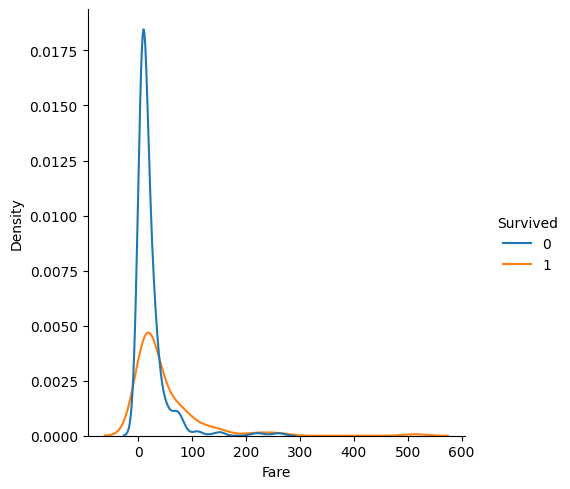

In [52]:
sns.displot(train, x="Fare", hue="Survived", kind="kde")


In [53]:
#  FS WoE & IV
def flags(df) :
  if ((df["Age"] >= 40) & (df["female"] == 1)):
    return 4
  elif ((df["Age"] >= 0) & ((df["Age"] <= 18) & (df["female"] == 1))):
    return 4
  elif ((df["Age"] < 40) & ((df["Age"] > 18) & (df["female"] == 1))):
    return 3
  elif ((df["Age"] >= 40) & ((df["female"] == 0))):
    return 2
  else :
    return 1

In [54]:
train3["age_and_sex"] = train3.apply(flags, axis =1)
train3

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,female,male,C,Q,S,age_and_sex
0,1,0,3,22.000000,1,0,7.2500,False,True,False,False,True,1
1,2,1,1,38.000000,1,0,71.2833,True,False,True,False,False,3
2,3,1,3,26.000000,0,0,7.9250,True,False,False,False,True,3
3,4,1,1,35.000000,1,0,53.1000,True,False,False,False,True,3
4,5,0,3,35.000000,0,0,8.0500,False,True,False,False,True,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,27.000000,0,0,13.0000,False,True,False,False,True,1
887,888,1,1,19.000000,0,0,30.0000,True,False,False,False,True,3
888,889,0,3,29.699118,1,2,23.4500,True,False,False,False,True,3
889,890,1,1,26.000000,0,0,30.0000,False,True,True,False,False,1


In [55]:
a = pd.crosstab(train3["age_and_sex"],train3["Survived"], margins=True, margins_name="Total")
a

Survived,0,1,Total
age_and_sex,,,
1,378,90,468
2,90,19,109
3,47,145,192
4,34,88,122
Total,549,342,891


In [57]:
total_nonevent = a[0]["Total"]
total_event = a[1]["Total"]


def nonevent(df) :
  return (df[0]/total_nonevent)
def event(df) :
  return (df[1]/total_event)
def Woe(df) :
  return ln(df["%nonevent"]/df["%event"])


a["%nonevent"] = a.apply(nonevent, axis =1 )
a["%event"] = a.apply(event, axis =1 )

a["WoE"] = np.log(a["%nonevent"]/a["%event"])
a["IV"] = (a["%nonevent"] - a["%event"])*a["WoE"]
a

Survived,0,1,Total,%nonevent,%event,WoE,IV
age_and_sex,,,,,,,
1,378,90,468,0.688525,0.263158,0.961797,0.409116
2,90,19,109,0.163934,0.055556,1.082083,0.117275
3,47,145,192,0.085610,0.423977,-1.599874,0.541344
4,34,88,122,0.061931,0.257310,-1.424264,0.278272
Total,549,342,891,1.000000,1.000000,0.000000,0.000000


In [58]:
a["IV"].sum()
train3

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,female,male,C,Q,S,age_and_sex
0,1,0,3,22.000000,1,0,7.2500,False,True,False,False,True,1
1,2,1,1,38.000000,1,0,71.2833,True,False,True,False,False,3
2,3,1,3,26.000000,0,0,7.9250,True,False,False,False,True,3
3,4,1,1,35.000000,1,0,53.1000,True,False,False,False,True,3
4,5,0,3,35.000000,0,0,8.0500,False,True,False,False,True,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,27.000000,0,0,13.0000,False,True,False,False,True,1
887,888,1,1,19.000000,0,0,30.0000,True,False,False,False,True,3
888,889,0,3,29.699118,1,2,23.4500,True,False,False,False,True,3
889,890,1,1,26.000000,0,0,30.0000,False,True,True,False,False,1


In [59]:
train3.describe()


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,age_and_sex
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208,1.964085
std,257.353842,0.486592,0.836071,13.002015,1.102743,0.806057,49.693429,1.135164
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000,1.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400,1.000000
50%,446.000000,0.000000,3.000000,29.699118,0.000000,0.000000,14.454200,1.000000
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000,3.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200,4.000000


In [60]:
def flags(df) :
  if ((df["Fare"] >= 35)):
    return 3
  elif (df["Fare"] >= 20):
    return 2
  else :
    return 1


In [61]:
train3["fare_category"] = train3.apply(flags, axis =1)
train3

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,female,male,C,Q,S,age_and_sex,fare_category
0,1,0,3,22.000000,1,0,7.2500,False,True,False,False,True,1,1
1,2,1,1,38.000000,1,0,71.2833,True,False,True,False,False,3,3
2,3,1,3,26.000000,0,0,7.9250,True,False,False,False,True,3,1
3,4,1,1,35.000000,1,0,53.1000,True,False,False,False,True,3,3
4,5,0,3,35.000000,0,0,8.0500,False,True,False,False,True,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,27.000000,0,0,13.0000,False,True,False,False,True,1,1
887,888,1,1,19.000000,0,0,30.0000,True,False,False,False,True,3,2
888,889,0,3,29.699118,1,2,23.4500,True,False,False,False,True,3,2
889,890,1,1,26.000000,0,0,30.0000,False,True,True,False,False,1,2


In [62]:
a = pd.crosstab(train3["fare_category"],train3["Survived"], margins=True, margins_name="Total")
a

Survived,0,1,Total
fare_category,,,
1,372,143,515
2,101,76,177
3,76,123,199
Total,549,342,891


In [63]:
total_nonevent = a[0]["Total"]
total_event = a[1]["Total"]


def nonevent(df) :
  return (df[0]/total_nonevent)
def event(df) :
  return (df[1]/total_event)
def Woe(df) :
  return ln(df["%nonevent"]/df["%event"])


a["%nonevent"] = a.apply(nonevent, axis =1 )
a["%event"] = a.apply(event, axis =1 )

a["WoE"] = np.log(a["%nonevent"]/a["%event"])
a["IV"] = (a["%nonevent"] - a["%event"])*a["WoE"]
a

Survived,0,1,Total,%nonevent,%event,WoE,IV
fare_category,,,,,,,
1,372,143,515,0.677596,0.418129,0.482762,0.125261
2,101,76,177,0.183971,0.222222,-0.188901,0.007226
3,76,123,199,0.138434,0.359649,-0.954739,0.211203
Total,549,342,891,1.000000,1.000000,0.000000,0.000000


In [64]:
a["IV"].sum()


np.float64(0.3436894793075985)